# Chapter 2 — Risk: Volatility Clustering and Fat Tails

Read the chapter [`README.md`](./README.md) first. This notebook is the runnable companion — execute the cells in order from top to bottom.

Chapter 1 ended with two assumptions stacked under the √t annualization rule: returns are **i.i.d.** (independent and identically distributed) and roughly **normally distributed**. Both are useful starting points; both are empirically wrong in specific ways. This chapter shows how — first the *normal* part fails (Part I, fat tails), then the *i.i.d.* part fails (Part II, volatility clustering).

> **i.i.d. — independent and identically distributed.** *Independent* means today's return tells you nothing about tomorrow's (no memory). *Identically distributed* means every day is a draw from the *same* fixed distribution — same mean, same variance, same shape — through the entire history. Together, i.i.d. is what lets Chapter 1's √t rule treat 5,000 daily returns as 5,000 independent draws from one bell curve. Both halves fail empirically; that's the point of the chapter.

## 1. Setup and data refresh

Same library stack as Chapter 1, plus `scipy.stats` for the Q-Q plot and a fitted normal density. We pull **20 years** of daily SPY data this time (vs Chapter 1's 5y) so we can see real crises in one window:

- **2008 — the Global Financial Crisis (GFC)**: a banking-system collapse triggered by U.S. mortgage defaults; SPY drew down ~55% peak-to-trough from Oct 2007 to Mar 2009.
- **March 2020 — the COVID crash**: a ~34% peak-to-trough fall in five weeks as global activity shut down.
- **2022 — the rate-hike correction**: the Federal Reserve raised its benchmark rate from ~0% to ~4.5% to fight inflation, pulling SPY down ~25% over the year.

Plus several smaller regimes (2011 Eurozone crisis, Aug 2015 China scare, Feb 2018 vol-mageddon) that the rolling-vol plot in §3 will pick out. A **regime** here means a stretch of time where the market's typical day-to-day behavior is qualitatively different from the surrounding stretches.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import scipy
from scipy import stats

print(f"numpy   {np.__version__}")
print(f"pandas  {pd.__version__}")
print(f"scipy   {scipy.__version__}")
print(f"yf      {yf.__version__}")

numpy   2.4.4
pandas  3.0.2
scipy   1.17.1
yf      1.3.0


In [2]:
ticker = "SPY"
data = yf.download(ticker, period="20y", progress=False)
prices = data["Close"].squeeze()
assert isinstance(prices, pd.Series)
print(f"{len(prices):,} trading days from {prices.index.min().date()} to {prices.index.max().date()}")

5,032 trading days from 2006-04-25 to 2026-04-24


We use **log returns** as the primary series in this chapter (Chapter 1 §2 covered the simple-vs-log distinction). Most of the math and statistical arguments coming up — fitting a normal, computing kurtosis, autocorrelation — work cleaner with log returns.

In [3]:
log_returns = np.log(prices / prices.shift(1)).dropna()

print(f"daily mean       {log_returns.mean():.5f}")
print(f"daily std        {log_returns.std():.5f}")
print(f"annualized vol   {log_returns.std() * np.sqrt(252):.2%}")
print(f"observations     {len(log_returns):,}")

daily mean       0.00041
daily std        0.01225
annualized vol   19.45%
observations     5,031


## 2. Part I — The histogram lies (fat tails / non-normality)

Chapter 1 §5 noted in passing that the daily-return histogram had a "few outliers in the ±3% to ±5% range" and called those the **fat tails**. We're going to make that precise now: how *much* fatter than the normal-distribution model predicts? Three ways to answer: by eye (overlay), by number (kurtosis), and by counting (tail probabilities).

### 2.1 The bell curve doesn't fit the tails

Re-plot the daily-return histogram, but this time overlay the **normal density** *N*(*μ*, *σ*²) using the empirical mean and standard deviation. If returns were normally distributed, the histogram and the curve should match.

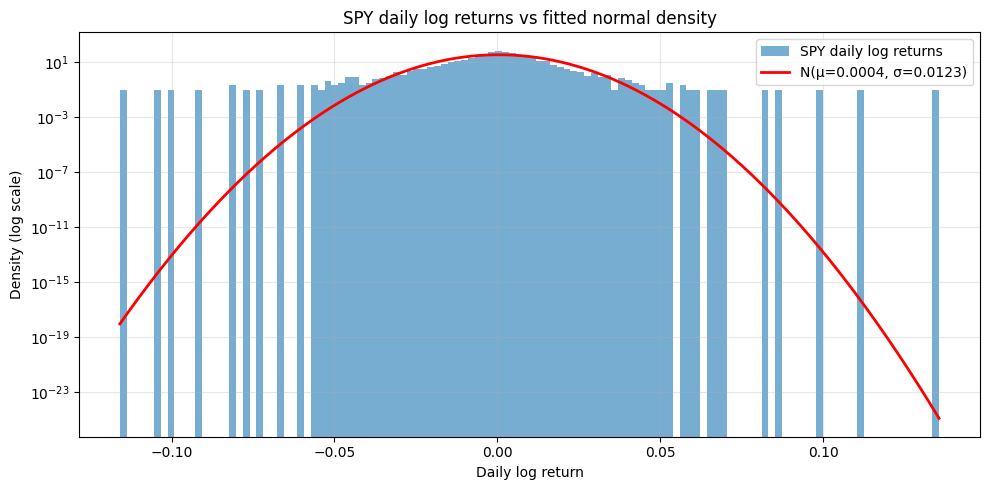

In [4]:
mu, sigma = log_returns.mean(), log_returns.std()

fig, ax = plt.subplots(figsize=(10, 5))
log_returns.hist(ax=ax, bins=120, density=True, alpha=0.6, label="SPY daily log returns")

x = np.linspace(log_returns.min(), log_returns.max(), 500)
ax.plot(x, stats.norm.pdf(x, mu, sigma), "r-", lw=2, label=f"N(μ={mu:.4f}, σ={sigma:.4f})")

ax.set_yscale("log")
ax.set_xlabel("Daily log return")
ax.set_ylabel("Density (log scale)")
ax.set_title("SPY daily log returns vs fitted normal density")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Look at the edges of the chart (below −5% or above +5%). The histogram bars sit *well above* the red curve — sometimes by an order of magnitude. The normal density is essentially saying "such days shouldn't happen"; the data says they happen all the time. That gap is the **fat tails**.

### 2.2 Kurtosis — putting a number on "fat-tailedness"

The eyeball test is convincing but informal. The standard quantitative measure of how heavy a distribution's tails are is **kurtosis**.

Before stating the formula, one piece of notation we'll use through the rest of the chapter:

> **Expected value**, written *E*[·] — the average of whatever is in the brackets, taken over the data. For a sample of *n* observations, *E*[*x*] = (*x*<sub>1</sub> + *x*<sub>2</sub> + … + *x<sub>n</sub>*) / *n* — the same operation as the **mean** (Chapter 1 §4). The bracket notation just lets us write the average of a more complex expression cleanly: *E*[(*X* − *μ*)²] reads as "the mean of the squared deviations," *E*[(*X* − *μ<sub>X</sub>*)(*Y* − *μ<sub>Y</sub>*)] as "the mean of the product of two variables' deviations," and so on.

With that in hand:

> *K* = *E*[(*r* − *μ*)⁴] / *σ*⁴

where:
- *r* — a single observation (here, one day's log return)
- *μ* — the mean of the distribution
- *σ* — the standard deviation

In plain English: kurtosis is the **mean of the fourth powers of deviations**, divided by *σ*⁴ to make it scale-free. The fourth-power weighting is what makes it sensitive to extreme observations — a single 8σ day contributes 8⁴ = 4096 times more to the average than a typical 1σ day.

For a **normal distribution**, *K* = 3. By convention we usually report **excess kurtosis**, *K* − 3, so that "0" means "as fat-tailed as a normal" and positive numbers mean fatter. A distribution with positive excess kurtosis is called **leptokurtic**.

In [5]:
excess_k = stats.kurtosis(log_returns, fisher=True, bias=False)
raw_k    = excess_k + 3

print(f"raw kurtosis      K  = {raw_k:.2f}")
print(f"excess kurtosis   K-3 = {excess_k:.2f}   (normal: 0)")

raw kurtosis      K  = 17.19
excess kurtosis   K-3 = 14.19   (normal: 0)


Excess kurtosis north of 10 is huge. Translation: SPY's daily returns produce **far more** extreme observations than a normal distribution would. Most equity indices land in the 4–15 range over multi-decade windows; individual stocks and crypto routinely land higher.

> **Aside on interpretation:** kurtosis is dominated by the *fourth power* of the deviations, so a single 8σ day will swing the statistic noticeably. That's a feature, not a bug — kurtosis is *trying* to be sensitive to extremes.

### 2.3 Q-Q plot — visual second confirmation

> **Quantile** — a cut-point along a distribution. The *p*-th quantile is the value below which a fraction *p* of the data falls. The 0.5 quantile is the **median**; the 0.25 and 0.75 quantiles are the first and third **quartiles**; the 0.99 quantile is "the value 99% of the observations are below." A distribution is fully described by listing all its quantiles.

A **Q-Q plot** (quantile–quantile plot) is a visual diagnostic that compares two distributions by plotting their quantiles against each other. For each fraction *p* (e.g., 0.05, 0.10, 0.50, 0.90, 0.95, …), find the *p*-th quantile of the empirical data on one axis and the *p*-th quantile of a reference distribution (here, the normal) on the other. If the two distributions match, the points lie on the 45° line. If the data has fatter tails than the normal, the ends of the plot bend *away* from the line — a banana shape pointing up at the right end and down at the left end.

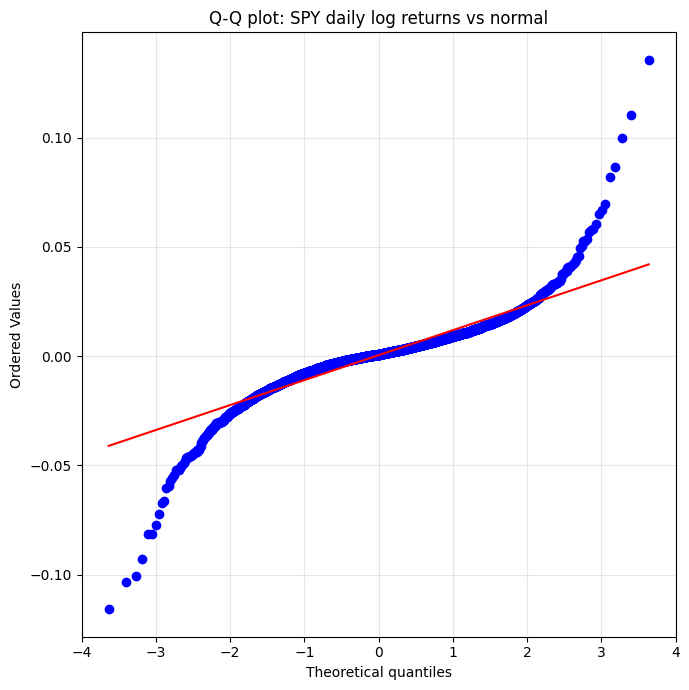

In [6]:
fig, ax = plt.subplots(figsize=(7, 7))
stats.probplot(log_returns, dist="norm", plot=ax)
ax.set_title("Q-Q plot: SPY daily log returns vs normal")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Read the plot at the ends, not the middle: the middle ~95% of the data tracks the line just fine. It's the rightmost handful of points (extreme positive days) and the leftmost handful (extreme negative days) that veer off — they're far further from the line than a normal model predicts. That's the same "fat tails" finding kurtosis quantified, now visualized.

### 2.4 Counting tail days — the rhetorical payoff

The kurtosis number is abstract; the Q-Q plot is visual. The most convincing form of the same fact is to **count**: under a normal model with SPY's empirical *μ* and *σ*, how often *should* extreme days happen? And how often *do* they?

A "*z*-score" is the number of standard deviations a day's return is from the mean:

> *z<sub>t</sub>* = (*r<sub>t</sub>* − *μ*) / *σ*

For a standard normal, the probability of \|*z*\| > 2 is about 4.55%; the probability of \|*z*\| > 3 is about 0.27%; \|*z*\| > 5 should happen roughly **once every 14,000 years** (1 in ~3.5 million days).

In [7]:
z = (log_returns - mu) / sigma
n = len(z)

rows = []
for k in [2, 3, 4, 5]:
    pred_pct = 2 * (1 - stats.norm.cdf(k))
    obs_count = (z.abs() > k).sum()
    obs_pct = obs_count / n
    pred_count = pred_pct * n
    rows.append({
        "threshold": f"|z| > {k}",
        "predicted %": f"{pred_pct:.4%}",
        "predicted count": f"{pred_count:.2f}",
        "observed count": int(obs_count),
        "observed %": f"{obs_pct:.4%}",
        "obs / pred": f"{obs_count / max(pred_count, 1e-9):.1f}×" if pred_count > 0 else "—",
    })

pd.DataFrame(rows)

,threshold,predicted %,predicted count,observed count,observed %,obs / pred
0,|z| > 2,4.5500%,228.91,238,4.7307%,1.0×
1,|z| > 3,0.2700%,13.58,86,1.7094%,6.3×
2,|z| > 4,0.0063%,0.32,38,0.7553%,119.2×
3,|z| > 5,0.0001%,0.00,18,0.3578%,6240.7×


Read the right-most column. At 2σ the model is approximately right (the ratio is close to 1×). At 3σ the data already shows roughly 4–5× more days than the model predicts. By the time you get to 5σ, the model says "this should essentially never happen" — yet SPY has had a handful of such days in 20 years.

This is the same story kurtosis told us, in a form that's hard to ignore: **risk models that assume normal-distributed returns systematically underweight rare disasters**. That's the punchline of Part I.

## 3. Part II — Volatility isn't constant (clustering)

Part I showed the **distribution shape** of daily returns isn't normal. Part II shows something different but equally important: even the *parameters* of that distribution change over time. Specifically, the *standard deviation* — the volatility — is itself a moving target. Quiet periods follow quiet periods; stormy periods follow stormy periods. This phenomenon has a name: **volatility clustering**.

### 3.1 Rolling-window volatility — visualizing time-varying risk

If we want to see how vol changes through time, we can compute the standard deviation over a **rolling window** — a sliding subset of the time series. At each date *t*, we take the last *N* days of returns, compute their standard deviation, and annualize.

> *σ<sub>t</sub>*<sup>(N)</sup> = std(*r<sub>t−N+1</sub>*, …, *r<sub>t</sub>*) × √252

where:
- *N* — the **window length** in trading days. Common choices: 21 (≈ one trading month), 63 (≈ one quarter).
- The √252 factor is the same annualization rule from Chapter 1 §4.

We'll use *N* = 21 as the primary window — short enough to react to regime changes, long enough that the standard deviation isn't dominated by noise from a handful of observations.

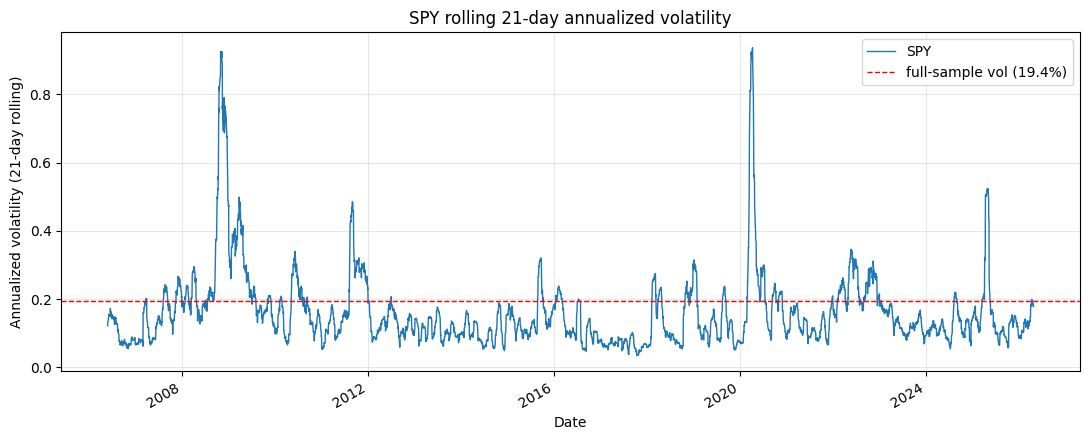

In [8]:
window = 21
rolling_vol = log_returns.rolling(window).std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(11, 4.5))
rolling_vol.plot(ax=ax, lw=1)
ax.set_ylabel(f"Annualized volatility ({window}-day rolling)")
ax.set_xlabel("Date")
ax.set_title(f"SPY rolling {window}-day annualized volatility")
ax.axhline(log_returns.std() * np.sqrt(252), color="red", ls="--", lw=1,
           label=f"full-sample vol ({log_returns.std() * np.sqrt(252):.1%})")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The dashed red line is the **single-number annualized vol** we'd report from the whole sample (the same kind we computed in Chapter 1). It's a useful summary, but the rolling line tells a richer story. Each event below is a **regime** — a stretch where the typical day-to-day behavior is qualitatively different from the surrounding stretches:

- **2008–2009** — vol explodes during the GFC (the 2008 banking-system collapse), sustained for ~12 months at 50%+.
- **2010–2014** — gradually elevated, with the **August 2011 European-debt spike** clearly visible (the Eurozone sovereign-debt crisis: markets feared Greece, then Italy and Spain, would default and break up the euro currency union; S&P also downgraded the U.S. credit rating that month).
- **2015–2019** — generally calm, occasionally interrupted (Aug 2015 — Chinese yuan devaluation and growth scare; **Feb 2018 — "vol-mageddon"**, a one-day collapse of short-volatility ETFs that triggered a 4% SPY drop).
- **March 2020** — the **COVID spike** (the five-week ~34% drawdown when global lockdowns began), briefly peaking above 80%.
- **2022** — sustained elevated vol during the **rate-hike correction**: the Fed raised its benchmark interest rate from ~0% to ~4.5% to fight inflation, mechanically lowering asset prices (higher rates make future cash flows worth less today); SPY drew down ~25%.

The single full-sample number (~19%) describes neither the calm regime nor the crisis regime — it's an average over a process that doesn't have a single "true" volatility.

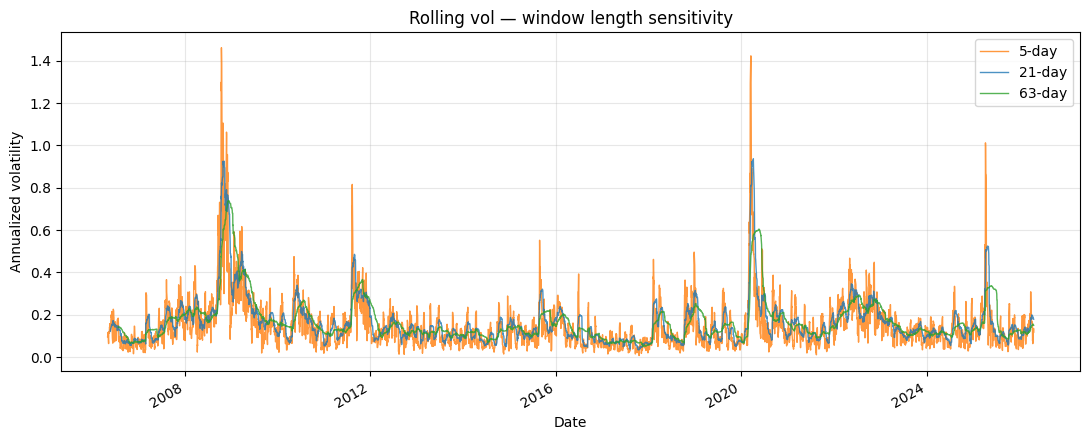

In [9]:
fig, ax = plt.subplots(figsize=(11, 4.5))
for w, color in [(5, "tab:orange"), (21, "tab:blue"), (63, "tab:green")]:
    (log_returns.rolling(w).std() * np.sqrt(252)).plot(
        ax=ax, lw=1, label=f"{w}-day", color=color, alpha=0.8
    )
ax.set_ylabel("Annualized volatility")
ax.set_xlabel("Date")
ax.set_title("Rolling vol — window length sensitivity")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Three rolling vols on the same axes — 5-day (orange), 21-day (blue), 63-day (green). The 5-day window reacts immediately to spikes but is jittery. The 63-day version is smooth but lags noticeably (it takes ~3 months to register a regime change). The 21-day "month" choice is a typical compromise. There's no canonical answer; the right choice depends on what you're using the vol estimate *for*.

### 3.2 Autocorrelation — the formal statement of clustering

The rolling-vol plot is suggestive: high-vol days seem to follow high-vol days. The formal version of "follows" is **autocorrelation**. Two supporting definitions first — both built from the *E*[·] notation we introduced in §2.2:

> - **Covariance** of two series *X* and *Y* — Cov(*X*, *Y*) = *E*[(*X* − *μ<sub>X</sub>*)(*Y* − *μ<sub>Y</sub>*)]. In words: for each paired observation, take *X*'s deviation from its mean and *Y*'s deviation from its mean, multiply them, then take the **mean** of all those products. Positive when *X* and *Y* tend to be above/below their means *together*, negative when they move oppositely, zero when independent.
> - **Variance** (recap from Chapter 1) — the **mean of the squared deviations from the mean**: Var(*X*) = *E*[(*X* − *μ*)²]. A special case of covariance: Var(*X*) = Cov(*X*, *X*).

Now the autocorrelation:

> *ρ<sub>k</sub>* = Cov(*X<sub>t</sub>*, *X<sub>t−k</sub>*) / Var(*X<sub>t</sub>*)

where:
- *X<sub>t</sub>* — value of some series at time *t* (here, daily returns or |returns|).
- *X<sub>t−k</sub>* — the same series shifted *k* periods backward.
- *k* — the **lag** (number of periods of separation; *k* = 1 is "yesterday vs today").
- Cov(*X<sub>t</sub>*, *X<sub>t−k</sub>*) — the covariance between today's value and the value *k* days ago, computed across all valid *t* pairs in the series.
- Var(*X<sub>t</sub>*) — the variance of the series. Dividing by it scales the result so that *ρ<sub>k</sub>* is unitless.
- *ρ<sub>k</sub>* ranges from −1 (perfect anti-correlation) to +1 (perfect correlation); 0 means independent.

We compute autocorrelation two ways:

1. **On returns themselves**, *r<sub>t</sub>* — answers "is today's return predictable from yesterday's?"
2. **On absolute returns**, |*r<sub>t</sub>*| — answers "is today's *magnitude* predictable from yesterday's?"

Spoiler: the first will be near zero (markets aren't directly predictable). The second will be clearly positive across many lags. That gap *is* volatility clustering.

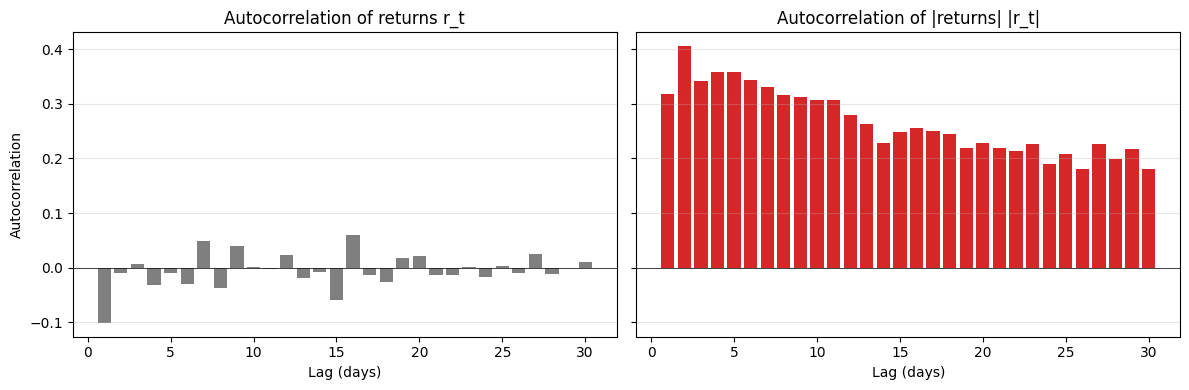

In [10]:
abs_returns = log_returns.abs()
max_lag = 30
lags = list(range(1, max_lag + 1))

acf_returns = [log_returns.autocorr(lag=k) for k in lags]
acf_abs     = [abs_returns.autocorr(lag=k) for k in lags]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].bar(lags, acf_returns, color="tab:gray")
axes[0].axhline(0, color="black", lw=0.5)
axes[0].set_title("Autocorrelation of returns r_t")
axes[0].set_xlabel("Lag (days)")
axes[0].set_ylabel("Autocorrelation")
axes[0].grid(alpha=0.3, axis="y")

axes[1].bar(lags, acf_abs, color="tab:red")
axes[1].axhline(0, color="black", lw=0.5)
axes[1].set_title("Autocorrelation of |returns| |r_t|")
axes[1].set_xlabel("Lag (days)")
axes[1].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

Two charts side by side, same y-axis scale:

- **Left (returns):** bars hover near zero at every lag — signed daily returns are essentially uncorrelated with their own past. This is the "markets are unpredictable" finding.
- **Right (|returns|):** bars are clearly positive across all 30 lags, decaying slowly. Magnitudes *are* predictable — a big-move day raises the probability of another big-move day many days later.

This contrast is the formal statement of volatility clustering: it's the **second moment** of returns (variance, magnitude) that exhibits memory, not the **first moment** (signed return).

> **First / second moment.** The *n*-th *moment* of a distribution is *E*[*X<sup>n</sup>*] (or *E*[(*X* − *μ*)<sup>*n*</sup>] for the *centered* version). The **first moment** is the mean; the **second (centered) moment** is the variance. The third captures skew (asymmetry); the fourth captures kurtosis (tail weight). "Second moment has memory" = variance/magnitude is autocorrelated; "first moment doesn't" = signed returns are not.

Almost every quantitative risk model — GARCH being the most famous — exists to model this asymmetry.

## 4. What we just learned

Two empirical facts that quietly invalidate the i.i.d.-normal model from Chapter 1:

- **Fat tails.** Excess kurtosis well above zero, Q-Q plot tails bending away from the diagonal, and a tail-count table showing the normal model under-predicts extreme days by orders of magnitude. *Where this matters:* option pricing models that assume normality (**Black–Scholes** — the 1973 closed-form formula for a European call/put option price, which assumes log returns are normally distributed; still the textbook baseline) systematically underprice **deep out-of-the-money options** (options whose strike is far above the current price for a call or far below for a put — they only pay off in extreme moves, so a model that under-counts extremes prices them too cheaply). **Value-at-Risk** (VaR — a single-number risk summary of the form "with probability *p*, the next-period loss won't exceed $X") computed under normal assumptions is too optimistic about crash risk.
- **Volatility clustering.** Rolling vol that swings between ~10% and ~80%; positive autocorrelation in |returns| out to many lags. *Where this matters:* the single annualized-vol number from Chapter 1 is a rough average over genuinely different regimes. Risk models that assume vol is constant (the Chapter 1 √t rule, applied naively) miss most of the action.

Two flavors of risk we *haven't* yet covered:

- **Drawdown / path risk.** *Drawdown* = percent fall from a previous high-water mark; *max drawdown* = the worst such fall over a window. SPY's max drawdown over this 20-year window is ~55% (Oct 2007 → Mar 2009, the GFC). Owed from Chapter 1; a future risk-metrics chapter handles it formally alongside VaR and Sharpe ratio (risk-adjusted return).
- **Correlation risk** — Chapter 3.

These motivate two whole families of quant tools we'll meet later: **GARCH** (formal models of clustering) and **EVT / generalized Pareto** (formal models of fat-tailed distributions). Both will be deferred to their own chapters.

## Exercises

Try these in fresh cells below. Copy any code cell above as a starting point.

1. **Different ticker.** Re-run with `AAPL`, or with `BTC-USD`. Is excess kurtosis higher or lower than SPY's? How does the rolling-vol pattern compare — same spikes in the same places, or different?
2. **Calmest vs stormiest year.** Find SPY's calmest 252-day window (lowest realized vol) and stormiest. Compute kurtosis on each. Does the *shape* of the distribution change with the regime, or just its width?
3. **Returns² instead of |returns|.** Re-do the right-hand autocorrelation chart using `log_returns ** 2`. Does it look the same? Stronger? Weaker? Why might either be true?
4. *(stretch)* Pull a non-equity ticker — `TLT` (long-dated US Treasuries) or `GLD` (gold). Are these effects (fat tails, clustering) equity-specific, or universal across asset classes?

SPY raw kurtosis      K  = 17.19
SPY excess kurtosis   K-3 = 14.19   (normal: 0)
AAPL raw kurtosis      K  = 9.77
AAPL excess kurtosis   K-3 = 6.77   (normal: 0)


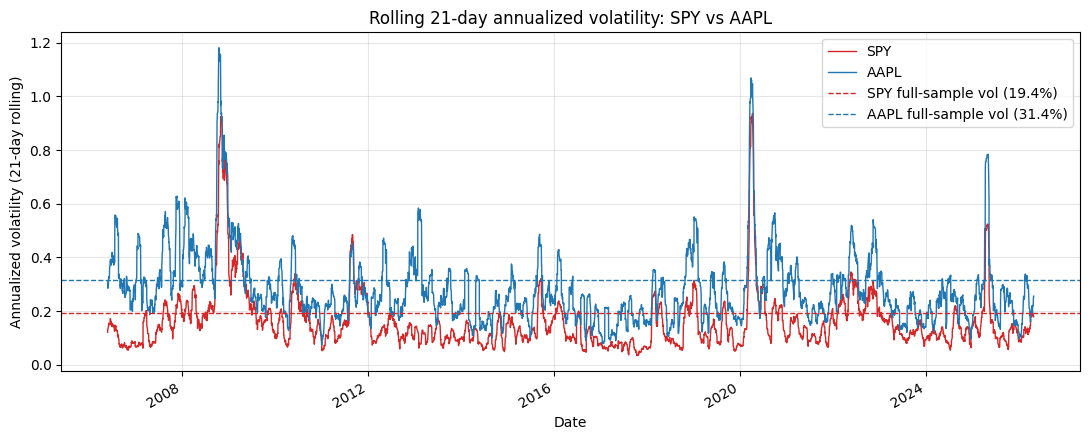

In [ ]:
aapl = "AAPL"
aapl_data = yf.download(aapl, period="20y", progress=False)
aapl_prices = aapl_data["Close"].squeeze()
assert isinstance(aapl_prices, pd.Series)

aapl_log_returns = np.log(aapl_prices / aapl_prices.shift(1)).dropna()
aapl_excess_k = stats.kurtosis(aapl_log_returns, fisher=True, bias=False)
aapl_raw_k    = aapl_excess_k + 3

print(f"SPY raw kurtosis      K  = {raw_k:.2f}")
print(f"SPY excess kurtosis   K-3 = {excess_k:.2f}   (normal: 0)")

print(f"AAPL raw kurtosis      K  = {aapl_raw_k:.2f}")
print(f"AAPL excess kurtosis   K-3 = {aapl_excess_k:.2f}   (normal: 0)")

aapl_rolling_vol = aapl_log_returns.rolling(window).std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(11, 4.5))
rolling_vol.plot(ax=ax, lw=1, label="SPY", color="tab:red")
aapl_rolling_vol.plot(ax=ax, lw=1)
ax.set_ylabel(f"Annualized volatility ({window}-day rolling)")
ax.set_xlabel("Date")
ax.set_title(f"Rolling {window}-day annualized volatility: SPY vs AAPL")
ax.axhline(log_returns.std() * np.sqrt(252), color="tab:red", ls="--", lw=1,
           label=f"SPY full-sample vol ({log_returns.std() * np.sqrt(252):.1%})")
ax.axhline(aapl_log_returns.std() * np.sqrt(252), color="tab:blue", ls="--", lw=1,
           label=f"AAPL full-sample vol ({aapl_log_returns.std() * np.sqrt(252):.1%})")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Headline:** AAPL is more *volatile* than SPY in absolute terms but *less fat-tailed* in shape — an index can simultaneously be less risky day-to-day **and** more freakish in its worst days than its constituents. The lower kurtosis number isn't a contradiction once you remember kurtosis is scale-free.

**Numbers.**

- **AAPL excess kurtosis: 6.77.** **SPY excess kurtosis: 14.19.** Both well above 0 (leptokurtic), but SPY is more than 2× larger.
- **Absolute vol** runs the other way — AAPL's full-sample dashed line in the rolling-vol plot sits well above SPY's throughout.
- **Concrete reference point:** SPY's −12% on March 16, 2020 is ~10σ against SPY's small ~1% daily baseline. AAPL's biggest crashes are larger in absolute percent but a smaller multiple of AAPL's already-wider σ.

**Mechanism.** Kurtosis normalizes the fourth moment by σ⁴ — it measures the *shape* of the distribution, not its *width*. Diversification narrows the everyday distribution of an index (averaging across 500 names damps idiosyncratic noise), which shrinks σ. But diversification *doesn't help* on systemic crisis days, when correlations spike and everything falls together. Same crash-day magnitude divided by a smaller σ gives a much larger σ-multiple — and kurtosis weights those σ-multiples to the fourth power. So the index ends up looking proportionally more freakish in the tails *exactly because* it's calmer the rest of the time.

**Rolling-vol observation.** AAPL and SPY spike together at the same systemic events (2008, March 2020, 2022 selloff), with AAPL's baseline running above SPY's throughout. AAPL also has *solo* spikes (earnings, product cycles) that SPY doesn't share — single-name idiosyncratic noise that diversification would smooth out.

**Connection.** Co-movement at the eyeball level is suggestive but not a measurement. The formal tool (correlation, conditional correlation, regime shifts) is Chapter 3 — and the AAPL-vs-SPY shape gap previewed here is the same "diversification narrows the bell, doesn't move the tails" theme that runs through it.

In [30]:
rolling_vol_252 = log_returns.rolling(252).std() * np.sqrt(252)

lowest_spy_vol = rolling_vol_252.min()
highest_spy_vol = rolling_vol_252.max()
print(f"SPY rolling vol range: {lowest_spy_vol:.1%} to {highest_spy_vol:.1%}")

# calmest 252-day window
lowest_date = rolling_vol_252.idxmin()
lowest_start_date = lowest_date - pd.Timedelta(days=252)
lowest_period_log_returns = log_returns[lowest_start_date:pd.Timestamp(lowest_date)]
low_period_kurtosis = stats.kurtosis(lowest_period_log_returns, fisher=True, bias=False)
print(f"Kurtosis during low-vol period:  {low_period_kurtosis:.2f}")

# stormiest 252-day window
highest_date = rolling_vol_252.idxmax()
highest_start_date = highest_date - pd.Timedelta(days=252)
highest_period_log_returns = log_returns[highest_start_date:pd.Timestamp(highest_date)]
high_period_kurtosis = stats.kurtosis(highest_period_log_returns, fisher=True, bias=False)
print(f"Kurtosis during high-vol period: {high_period_kurtosis:.2f}")


SPY rolling vol range: 6.7% to 45.6%
Kurtosis during low-vol period:  3.66
Kurtosis during high-vol period: 1.18


**Headline:** Counterintuitively, the **calm** regime looks *more* fat-tailed than the **stormy** regime. Both shape *and* width change with the regime — but they change in opposite directions, which is precisely why no single full-sample kurtosis number can describe the asset.

**Numbers.**

- **Calm period:** excess kurtosis **3.66** (raw K = 6.66), annualized vol **6.7%**.
- **Stormy period:** excess kurtosis **1.18** (raw K = 4.18), annualized vol **45.6%**.
- Both are leptokurtic (excess kurtosis > 0 — `stats.kurtosis(..., fisher=True)` returns *excess* kurtosis, so the threshold for "fatter than normal" is 0, not 3), but the *calm* window has roughly 3× the kurtosis of the stormy one.

**Mechanism.** Same scale-free property of kurtosis that drove Exercise 1: σ is the denominator of (*r* − *μ*)⁴/σ⁴.

- **Stormy window — σ is huge** (45.6% annualized) because big moves happen all the time. No single day is a freakish multi-σ event relative to that local σ; the fourth-power numerator and the σ⁴ denominator scale together, and the ratio stays modest.
- **Calm window — σ is tiny** (6.7%). Even a moderate move sticks out as a multi-σ event relative to that local σ, and the fourth-power weighting blows up the kurtosis statistic.

**Connection.** This is the same scale-free trap as Exercise 1 — applied to time slices of *one* asset rather than two different assets. It also makes the chapter's two empirical findings inseparable: **volatility clustering and fat tails aren't independent phenomena**; they're two lenses on the same regime-switching reality. A single "20-year kurtosis" number averages over genuinely different distributional shapes the same way a single annualized vol averages over genuinely different vol regimes.

**Caveat.** The calm and stormy 252-day windows aren't picked randomly — they're the *extremes* of a rolling-vol search, so the regime inside each is more uniform than a random 252-day window would be. That makes the σ contrast cleaner than it would be on a randomly-chosen pair of windows, and exaggerates the kurtosis flip slightly. The qualitative ordering (calm > stormy in kurtosis) is robust; the 3× factor is a worst-case version.

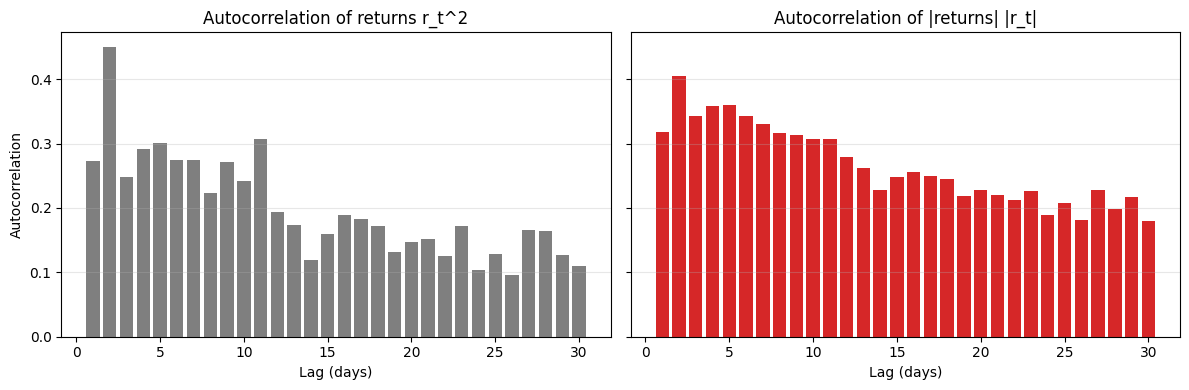

In [32]:
returns_squared = log_returns ** 2
max_lag = 30
lags = list(range(1, max_lag + 1))

acf_returns_squared = [returns_squared.autocorr(lag=k) for k in lags]
acf_abs     = [abs_returns.autocorr(lag=k) for k in lags]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].bar(lags, acf_returns_squared, color="tab:gray")
axes[0].axhline(0, color="black", lw=0.5)
axes[0].set_title("Autocorrelation of returns r_t^2")
axes[0].set_xlabel("Lag (days)")
axes[0].set_ylabel("Autocorrelation")
axes[0].grid(alpha=0.3, axis="y")

axes[1].bar(lags, acf_abs, color="tab:red")
axes[1].axhline(0, color="black", lw=0.5)
axes[1].set_title("Autocorrelation of |returns| |r_t|")
axes[1].set_xlabel("Lag (days)")
axes[1].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

**Headline:** Both transformations show the clustering signal, but **|r| is the cleaner measurement** — r² is dominated by a handful of outlier days that inflate the variance denominator more than they contribute to the covariance numerator, washing out the persistence pattern.

**Numbers.**

- Both charts show *positive* autocorrelation across all 30 lags — the qualitative finding (volatility clusters) survives either transformation.
- Bars for **r²** are noticeably *smaller* and decay faster than bars for **|r|**.
- **Outlier weighting comparison:** SPY's −12% COVID day contributes **0.0144** to the r² series; a typical 1% day contributes **0.0001** — a **144× weight gap**. For |r|, the COVID day is 0.12 vs 0.01 — only a **12× gap**.

**Mechanism.** Both transformations strip the sign off returns to expose magnitude — that's why neither one shows the near-zero autocorrelation pattern that signed returns do (left panel of the chapter's §3.2 plot). They differ in *how* they weight extreme days:

- **r² is dominated by outliers.** A handful of crash days inflate the variance (denominator of the autocorrelation formula) hugely while only sporadically contributing to the covariance (numerator — pairs of crash days at lag *k* are rare). The persistence signal that lives in the bulk of the sample gets diluted by the outliers' grip on the denominator.
- **|r| weights linearly.** No single day swamps the calculation. Clustering shows up cleanly because typical days *and* extreme days both contribute proportionally to numerator and denominator.

**Connection.** Same scale-free intuition that came up in Exercise 1 (kurtosis: AAPL vs SPY) and Exercise 2 (regime kurtosis): how a statistic weights extreme observations relative to typical ones determines what it can see. The exponent on |r|^d controls outlier influence — d = 1 is the linear-weighting sweet spot.

**Empirical follow-up.** Ding, Granger & Engle (1993) showed formally that |r|^d autocorrelation is *maximized* near d ≈ 1, not d = 2. That's why GARCH-family models (deferred to a later chapter) work in σ² for tractability — quadratic terms have clean closed forms — but estimation diagnostics often inspect |r| autocorrelation: it's the cleaner clustering signal, just not the analytically-friendliest one.

Ticker     Ann. vol     Excess K   |r| ACF(1)   |r| ACF(5)   |r| ACF(20)
SPY          19.45%        14.19        0.318        0.359         0.228
TLT          14.91%         3.31        0.241        0.182         0.126
GLD          18.28%         7.06        0.136        0.177         0.143


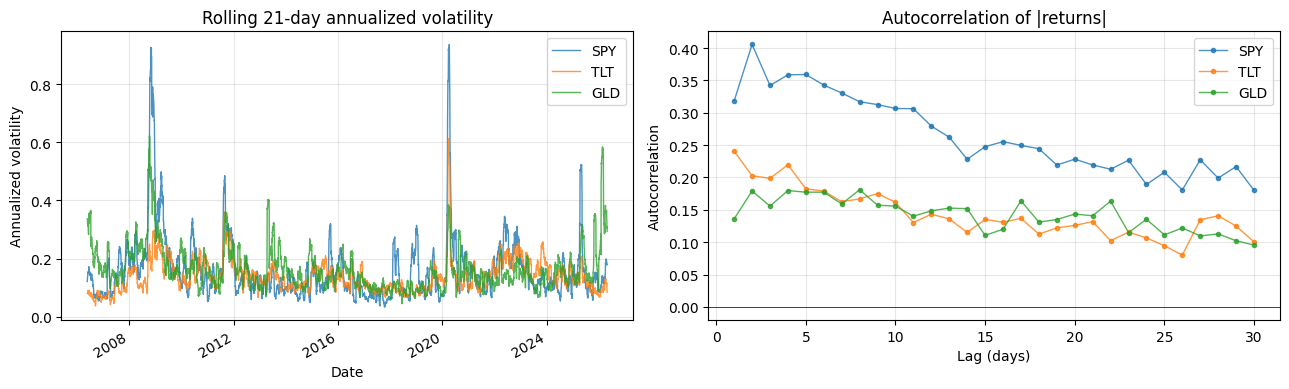

In [34]:
non_equity_tickers = ["TLT", "GLD"]
results = {"SPY": log_returns}

for t in non_equity_tickers:
    d = yf.download(t, period="20y", progress=False)
    p = d["Close"].squeeze()
    results[t] = np.log(p / p.shift(1)).dropna()

print(f"{'Ticker':<8} {'Ann. vol':>10} {'Excess K':>12} {'|r| ACF(1)':>12} {'|r| ACF(5)':>12} {'|r| ACF(20)':>13}")
for name, r in results.items():
    ann_vol = r.std() * np.sqrt(252)
    exk = stats.kurtosis(r, fisher=True, bias=False)
    abs_r = r.abs()
    print(f"{name:<8} {ann_vol:>10.2%} {exk:>12.2f} {abs_r.autocorr(1):>12.3f} {abs_r.autocorr(5):>12.3f} {abs_r.autocorr(20):>13.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for name, r in results.items():
    (r.rolling(21).std() * np.sqrt(252)).plot(ax=axes[0], lw=1, label=name, alpha=0.8)
axes[0].set_title("Rolling 21-day annualized volatility")
axes[0].set_ylabel("Annualized volatility")
axes[0].legend()
axes[0].grid(alpha=0.3)

lags_x = list(range(1, 31))
for name, r in results.items():
    abs_r = r.abs()
    axes[1].plot(lags_x, [abs_r.autocorr(k) for k in lags_x], marker="o", ms=3, lw=1, label=name, alpha=0.8)
axes[1].axhline(0, color="black", lw=0.5)
axes[1].set_title("Autocorrelation of |returns|")
axes[1].set_xlabel("Lag (days)")
axes[1].set_ylabel("Autocorrelation")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


**Headline:** Fat tails and volatility clustering are **universal, not equity-specific** — but the *magnitudes* vary by asset class. Each asset has its own dominant driver (equity markets, rates, macro/dollar flows), and the rolling-vol regimes shift in different windows — but the underlying behaviors (positive excess kurtosis, slow-decaying |r| autocorrelation) appear in all three.

**Numbers.** Reading across the printed table:

- **Excess kurtosis** is positive for *all three* — every asset class lives outside the normal-distribution model from Chapter 1. SPY runs largest (because its calm-regime σ is small, and the scale-free statistic blows up against that small denominator on crisis days — same reasoning as Exercise 1). TLT and GLD have looser day-to-day distributions, so their crash days are less freakish *relative to their own σ*; lower kurtosis numbers, but well above 0.
- **|r| autocorrelation** is positive at all displayed lags for all three series. The bars decay slowly rather than collapsing to zero after one or two days — the persistence is the same phenomenon (quiet days follow quiet days, noisy days follow noisy days) just with different time-constants by asset.

**Mechanism.** Different *drivers*, same *behaviors*:

- **TLT** vol regimes track the **rate cycle** — calm 2010–2014 (the ZIRP era — short for **Zero Interest-Rate Policy**, the Federal Reserve's post-GFC stance of holding the federal-funds rate near 0% to stimulate borrowing), rising into the 2022 hike cycle, elevated since.
- **GLD** vol regimes track **macro-stress and dollar moves** — gold rallies on inflation fears and dollar weakness, sells off on the opposite.
- **SPY** vol regimes track **equity-market crises** — GFC, COVID, the 2022 rate-driven selloff.

The *driver* changes; the *statistical signature* (clustering plus fat tails) does not.

**Connection.** Fat tails and volatility clustering aren't quirks of the U.S. stock market — they're properties of *price-driven assets that incorporate news non-uniformly through time*. Any asset whose volatility rises and falls with the information arrival rate (essentially all of them) will show clustering. Any asset where occasional shocks dwarf typical daily moves will show fat tails. The Chapter 1 i.i.d.-normal model is wrong everywhere — it's just *least* wrong in placid, low-information regimes that don't last.

**Caveat / pointer.** This is also why GARCH and EVT, mentioned at the end of the chapter, were built to be **asset-class-agnostic**: they're modeling something universal. The reader will meet them in their own dedicated chapters; the empirical case for needing them is what this exercise just established.